## 🎯 Learning Outcomes

### By the end of this module, you will be able to:

- **Matplotlib architecture**: Figure, Axes, Artist
- **Pyplot** vs the **object-oriented** interface
- **Basic charts**: line, scatter, bar, histogram, pie
- **Customization** (colors, styles, legends) and **subplots**
- **Saving figures** for reports and slides
- **Seaborn** for statistical plots: distributions, categorical, relational, heatmaps, pair plots

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("matplotlib:", plt.matplotlib.__version__)
print("seaborn   :", sns.__version__)

matplotlib: 3.10.0
seaborn   : 0.13.2


## Part 1 — Matplotlib Architecture

| Layer | What it is |
|---|---|
| **Figure** | the whole canvas — your window or saved image |
| **Axes** | one chart inside the figure, with its own x/y axes |
| **Artist** | every drawable element: lines, text, ticks, legend |

A Figure can hold many Axes. Almost every customization changes some Artist's properties.

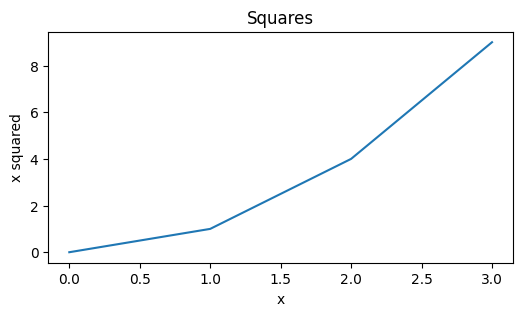

In [2]:
# -- Single-axes figure --------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))   # 1 figure, 1 axes
ax.plot([0, 1, 2, 3], [0, 1, 4, 9])
ax.set_title('Squares')
ax.set_xlabel('x')
ax.set_ylabel('x squared')
plt.show()

## Part 2 — Pyplot vs the Object-Oriented Interface

Matplotlib offers two styles. They produce identical results.

| Style | When to use |
|---|---|
| **Pyplot** (`plt.plot`, `plt.title`) | quick, one-off plots; MATLAB-like |
| **Object-Oriented** (`fig, ax = plt.subplots(); ax.plot(...)`) | anything you'll customize, save, or extend — recommended |

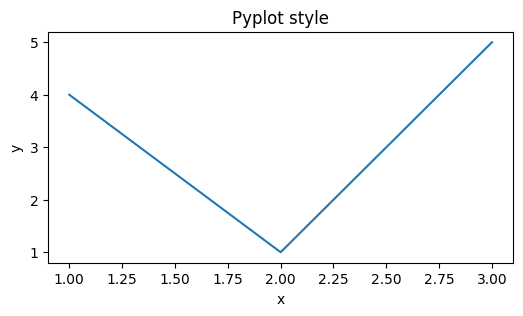

In [3]:
# -- Pyplot style: short and quick ---------------------------------------------
plt.figure(figsize=(6, 3))
plt.plot([1, 2, 3], [4, 1, 5])
plt.title('Pyplot style')
plt.xlabel('x'); plt.ylabel('y')
plt.show()

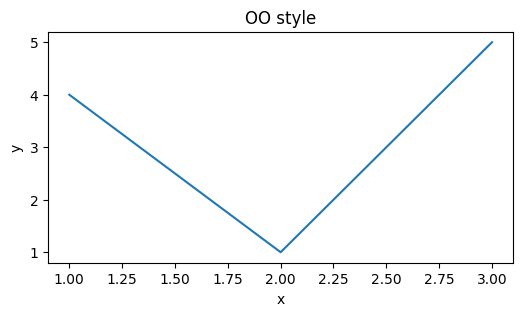

In [4]:
# -- OO style: explicit, scales to multi-panel figures -------------------------
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3], [4, 1, 5])
ax.set_title('OO style')
ax.set(xlabel='x', ylabel='y')           # combined setter
plt.show()

## Part 3 — Basic Charts

| Chart | Use it for |
|---|---|
| line | ordered or continuous data over an axis (often time) |
| scatter | relationship between two numeric variables |
| bar | comparing categories |
| histogram | distribution of one numeric variable |
| pie | shares of a whole (use sparingly — bars are usually clearer) |

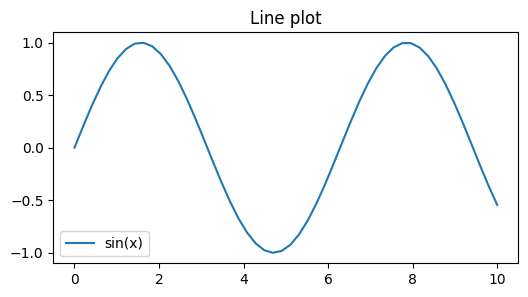

In [5]:
x = np.linspace(0, 10, 50)
y = np.sin(x)

# -- Line plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(x, y, label='sin(x)')
ax.set_title('Line plot')
ax.legend()
plt.show()

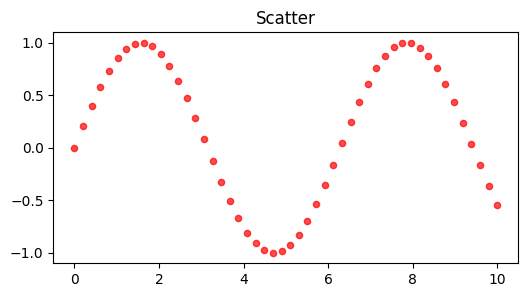

In [6]:
# -- Scatter plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))
ax.scatter(x, y, s=20, c='red', alpha=0.7)
ax.set_title('Scatter')
plt.show()

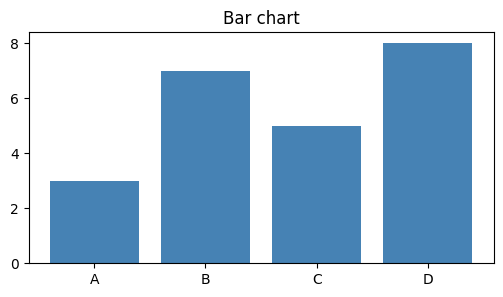

In [7]:
# -- Bar chart -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(['A', 'B', 'C', 'D'], [3, 7, 5, 8], color='steelblue')
ax.set_title('Bar chart')
plt.show()

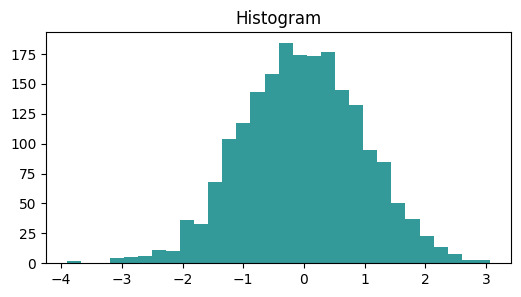

In [8]:
# -- Histogram -----------------------------------------------------------------
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(rng.standard_normal(2000), bins=30, color='teal', alpha=0.8)
ax.set_title('Histogram')
plt.show()

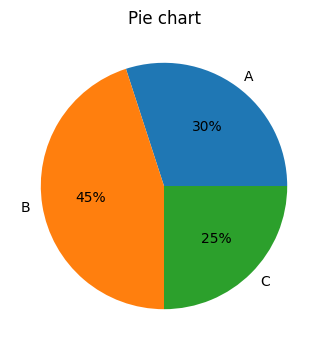

In [9]:
# -- Pie chart -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4, 4))
ax.pie([30, 45, 25], labels=['A', 'B', 'C'], autopct='%.0f%%')
ax.set_title('Pie chart')
plt.show()

## Part 4 — Customization and Subplots

A 2×2 grid of subplots, each customized independently. Note the rich set of options on each `ax.plot()` call.

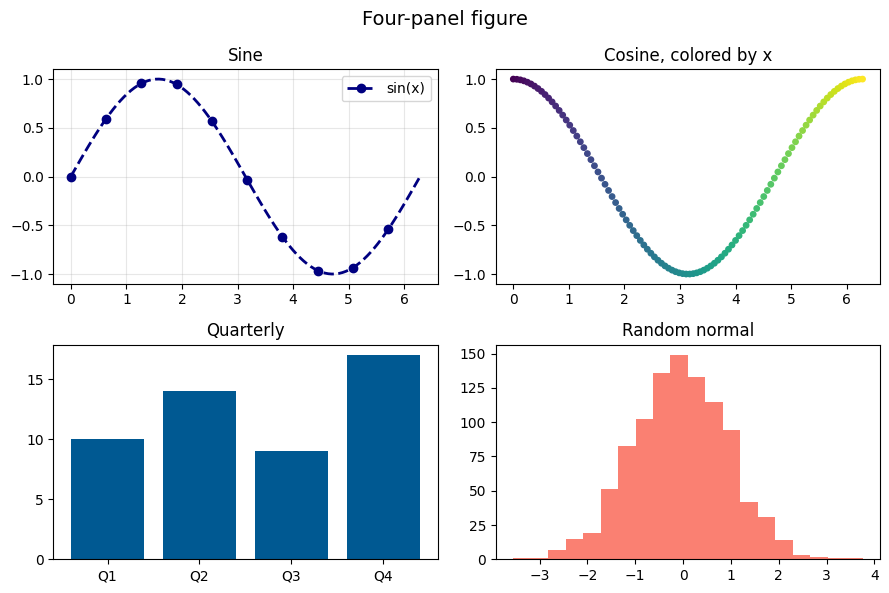

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
x = np.linspace(0, 2*np.pi, 100)

# -- Top-left: line with style -------------------------------------------------
axes[0, 0].plot(x, np.sin(x),
                color='navy', linestyle='--', linewidth=2,
                marker='o', markevery=10, label='sin(x)')
axes[0, 0].set_title('Sine')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].legend(loc='upper right')

# -- Top-right: scatter colored by a third variable ----------------------------
axes[0, 1].scatter(x, np.cos(x), c=x, cmap='viridis', s=15)
axes[0, 1].set_title('Cosine, colored by x')

# -- Bottom-left: bar chart ---------------------------------------------------
axes[1, 0].bar(['Q1','Q2','Q3','Q4'], [10, 14, 9, 17], color='#005992')
axes[1, 0].set_title('Quarterly')

# -- Bottom-right: histogram ---------------------------------------------------
axes[1, 1].hist(np.random.default_rng(1).standard_normal(1000), bins=20, color='salmon')
axes[1, 1].set_title('Random normal')

fig.suptitle('Four-panel figure', fontsize=14)
fig.tight_layout()
plt.show()

## Part 5 — Saving Figures

`savefig` accepts PNG, SVG, and PDF. Standard recipe:

- `dpi=300` for print
- `bbox_inches='tight'` to crop white space
- SVG / PDF for vector quality in reports and slides

files saved:
  /tmp/my_plot.png: 29,639 bytes
  /tmp/my_plot.pdf: 8,681 bytes


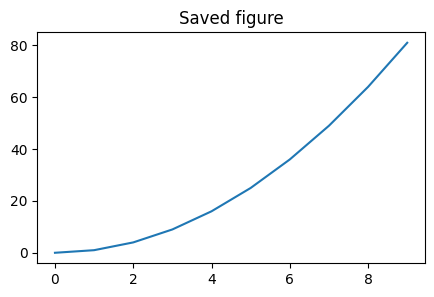

In [11]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(np.arange(10), np.arange(10) ** 2)
ax.set_title('Saved figure')

# -- Save as PNG (raster) and PDF (vector) -------------------------------------
fig.savefig('/tmp/my_plot.png', dpi=200, bbox_inches='tight')
fig.savefig('/tmp/my_plot.pdf',          bbox_inches='tight')

print('files saved:')
import os
for p in ('/tmp/my_plot.png', '/tmp/my_plot.pdf'):
    print(f'  {p}: {os.path.getsize(p):,} bytes')
plt.show()

## Part 6 — Seaborn: Statistical Plotting

Seaborn understands DataFrames natively. Pass `data=df` and column names as **strings**. Defaults look better, code is shorter, and it handles legends and statistical aesthetics for you.

In [12]:
sns.set_theme(style='whitegrid')

# -- Build a synthetic dataset for the rest of this section --------------------
rng = np.random.default_rng(42)
n = 300
df = pd.DataFrame({
    'age':    rng.integers(18, 65, size=n),
    'score':  rng.normal(75, 12, size=n).clip(0, 100),
    'hours':  rng.uniform(0, 12, size=n),
    'dept':   rng.choice(['CS', 'EE', 'ME', 'IS'], size=n, p=[0.4, 0.3, 0.2, 0.1]),
    'gender': rng.choice(['F', 'M'], size=n),
})
df.head()

,age,score,hours,dept,gender
0,22,87.791763,11.287133,CS,F
1,54,76.884583,1.781268,CS,M
2,48,73.096382,6.100233,EE,M
3,38,62.572155,4.848413,CS,F
4,38,54.903805,5.690025,EE,M


## Part 7 — Distribution Plots

| Function | Shows |
|---|---|
| `histplot` | binned counts (with optional KDE overlay) |
| `kdeplot` | smoothed density |
| `ecdfplot` | empirical cumulative distribution |

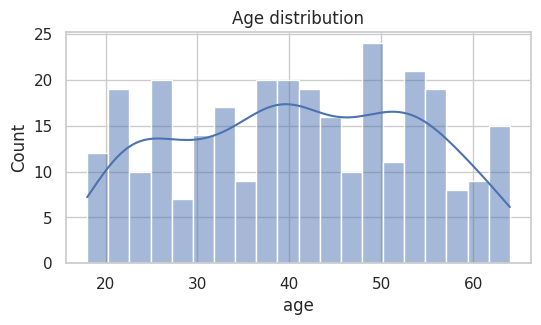

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
sns.histplot(data=df, x='age', bins=20, kde=True, ax=ax)
ax.set_title('Age distribution')
plt.show()

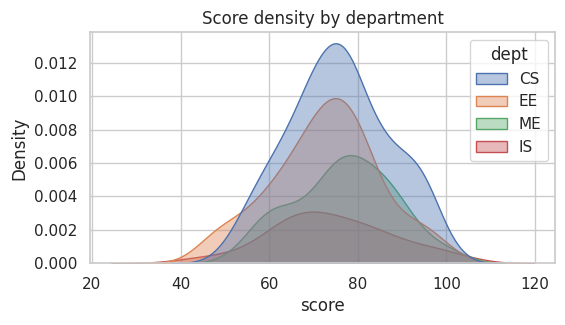

In [14]:
# -- KDE split by group --------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 3))
sns.kdeplot(data=df, x='score', hue='dept', fill=True, alpha=0.4, ax=ax)
ax.set_title('Score density by department')
plt.show()

## Part 8 — Categorical Plots

| Function | Shows |
|---|---|
| `boxplot` | quartiles + outliers |
| `violinplot` | density at every level |
| `stripplot` | raw points (with jitter) |
| `barplot` | aggregate (default: mean with 95% CI) |
| `countplot` | frequencies |

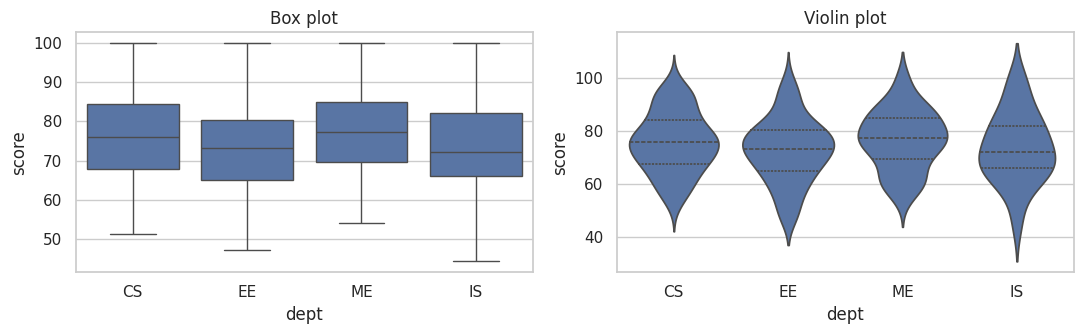

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(data=df, x='dept', y='score', ax=axes[0])
axes[0].set_title('Box plot')

sns.violinplot(data=df, x='dept', y='score', inner='quartile', ax=axes[1])
axes[1].set_title('Violin plot')

plt.tight_layout(); plt.show()

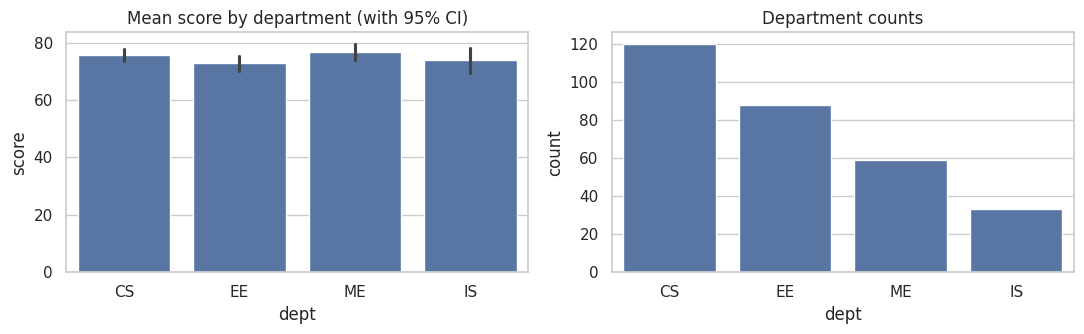

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
sns.barplot(data=df, x='dept', y='score', estimator='mean', ax=axes[0])
axes[0].set_title('Mean score by department (with 95% CI)')

sns.countplot(data=df, x='dept', ax=axes[1])
axes[1].set_title('Department counts')

plt.tight_layout(); plt.show()

## Part 9 — Relational Plots

`hue`, `size`, and `style` map columns to color, marker size, and marker shape — letting you encode up to **five dimensions** on a 2-D chart.

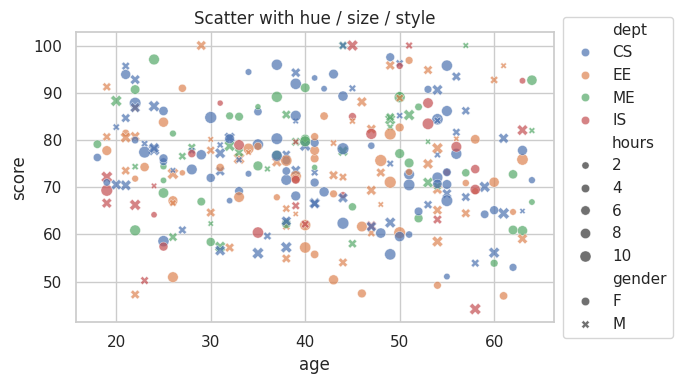

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x='age', y='score',
    hue='dept',         # <- color by department
    size='hours',       # <- marker size by hours
    style='gender',     # <- marker shape by gender
    alpha=0.7, ax=ax,
)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
ax.set_title('Scatter with hue / size / style')
plt.tight_layout()
plt.show()

## Part 10 — Heatmaps and Pair Plots

| Function | Shows |
|---|---|
| `heatmap` | matrix as colored cells (correlations, confusion matrices) |
| `pairplot` | every numeric pair on a grid |

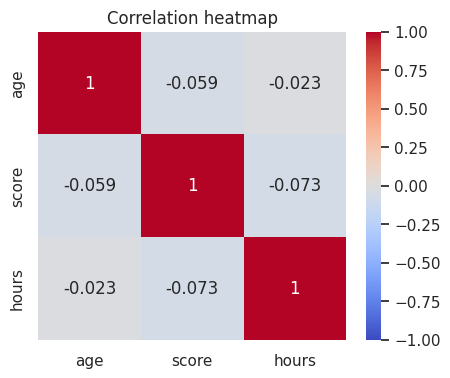

In [18]:
# -- Correlation heatmap -------------------------------------------------------
corr = df.select_dtypes('number').corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Correlation heatmap')
plt.show()

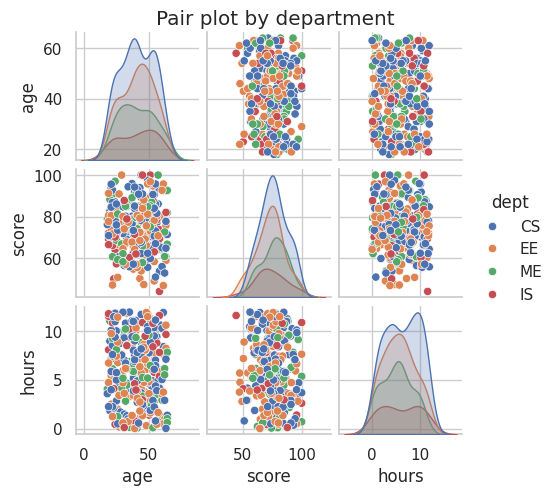

In [19]:
# -- Pair plot returns a FacetGrid (figure-level); cannot pass ax= -------------
g = sns.pairplot(df, hue='dept', diag_kind='kde', height=1.6)
g.fig.suptitle('Pair plot by department', y=1.02)
plt.show()

---

## Part 11 — Visualising Real Data from a CSV

Everything in Parts 1–10 used synthetic arrays. Now we load **`students_scores.csv`** — 15 real rows with Math, Science, English scores, attendance, and a pass/fail flag — and build a progression of charts that tell a complete story about the class.

Each chart below maps directly to a chart type you learned above, so you can see exactly how the same techniques apply when data comes from a file instead of `np.random`.

| Chart | Technique from |
|---|---|
| Horizontal bar — average scores per subject | Part 3 bar |
| Histogram — score distributions with KDE | Part 7 `histplot` |
| Scatter — Math vs Science colored by pass/fail | Part 9 `scatterplot` |
| Box — score spread per subject | Part 8 `boxplot` |
| KDE — attendance by pass/fail group | Part 7 `kdeplot` |
| Heatmap — subject correlation matrix | Part 10 `heatmap` |
| 6-panel dashboard — everything together | Part 4 subplots |

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# -- Load the CSV and add two derived columns --------------------------
df = pd.read_csv('students_scores.csv')

df['weighted_avg'] = (
    df['math_score']    * 0.40 +
    df['science_score'] * 0.35 +
    df['english_score'] * 0.25
).round(1)

df['grade'] = pd.cut(
    df['math_score'],
    bins=[0, 49, 59, 69, 79, 100],
    labels=['F', 'D', 'C', 'B', 'A']
)

print(f'Loaded {len(df)} students, {df.columns.tolist()}')
df[['name','math_score','science_score','english_score',
    'attendance_pct','passed','weighted_avg','grade']].head()

Loaded 15 students, ['student_id', 'name', 'age', 'math_score', 'science_score', 'english_score', 'attendance_pct', 'passed', 'weighted_avg', 'grade']


,name,math_score,science_score,english_score,attendance_pct,passed,weighted_avg,grade
0,Ali Hassan,88,92,75,96.5,True,86.2,A
1,Sara Al-Mutairi,72,68,84,88.0,True,73.6,B
2,Khalid Nasser,55,60,58,74.5,False,57.5,D
3,Fatima Al-Zahra,95,97,91,99.0,True,94.7,A
4,Omar Bin Saleh,43,50,62,65.0,False,50.2,F


### Chart 1 — Horizontal bar: class average per subject

A bar chart is the clearest way to **compare a single metric across categories**. We sort by value and annotate each bar so the reader never needs to read the axis.

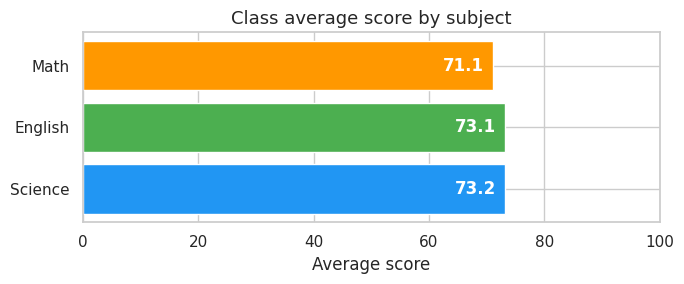

In [21]:
subjects = ['math_score', 'science_score', 'english_score']
labels   = ['Math', 'Science', 'English']
averages = [df[s].mean() for s in subjects]

# Sort highest to lowest
order    = sorted(range(3), key=lambda i: averages[i], reverse=True)
labels   = [labels[i]   for i in order]
averages = [averages[i] for i in order]

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(labels, averages, color=['#2196F3','#4CAF50','#FF9800'])

# Annotate each bar with its value
for bar, val in zip(bars, averages):
    ax.text(val - 1.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', ha='right',
            color='white', fontweight='bold')

ax.set_xlim(0, 100)
ax.set_xlabel('Average score')
ax.set_title('Class average score by subject', fontsize=13)
plt.tight_layout()
plt.show()

### Chart 2 — Overlapping histograms: score distributions

Overlapping `histplot` calls with `alpha < 1` let you compare how each subject's scores are spread — all in a single glance.

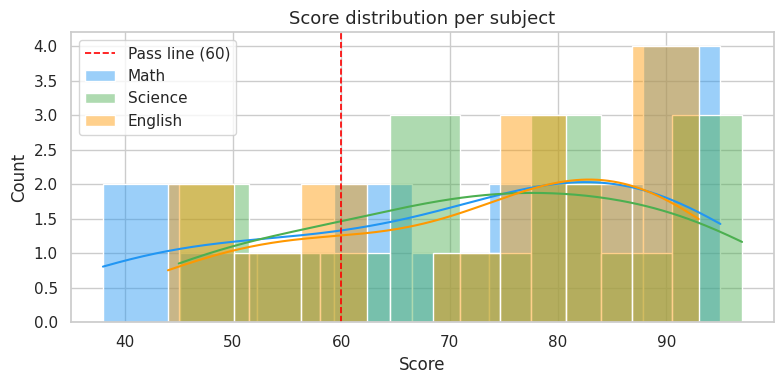

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))

palette = {'Math': '#2196F3', 'Science': '#4CAF50', 'English': '#FF9800'}
for col, label in zip(subjects, palette):
    sns.histplot(
        df[col], bins=8, kde=True,
        label=label, color=palette[label],
        alpha=0.45, ax=ax
    )

ax.axvline(60, color='red', linestyle='--', linewidth=1.2, label='Pass line (60)')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score distribution per subject', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

### Chart 3 — Scatter: Math vs Science, colored by pass/fail

A scatter plot reveals **correlation between two numeric variables** and the `hue` parameter instantly highlights which group each student belongs to. Annotating every point by name works well for small datasets.

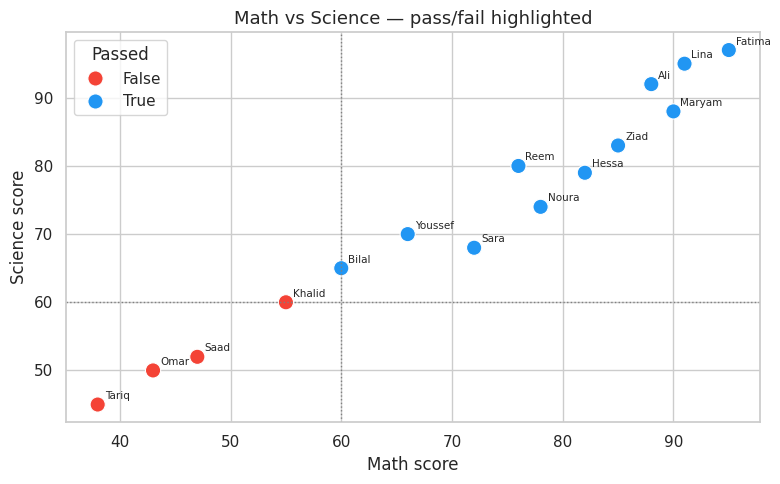

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='math_score', y='science_score',
    hue='passed',
    palette={True: '#2196F3', False: '#F44336'},
    s=120, edgecolor='white', linewidth=0.8,
    ax=ax
)

# Annotate every student with their first name
for _, row in df.iterrows():
    first = row['name'].split()[0]
    ax.annotate(first, (row['math_score'], row['science_score']),
                textcoords='offset points', xytext=(5, 4), fontsize=7.5)

# Draw pass threshold lines
ax.axvline(60, color='grey', linestyle=':', linewidth=1)
ax.axhline(60, color='grey', linestyle=':', linewidth=1)

ax.set_xlabel('Math score')
ax.set_ylabel('Science score')
ax.set_title('Math vs Science — pass/fail highlighted', fontsize=13)
ax.legend(title='Passed')
plt.tight_layout()
plt.show()

### Chart 4 — Box plot: score spread per subject

Box plots show the **median, IQR, and outliers** in one compact shape — much more informative than a single average. We melt the wide DataFrame into long format first, which is the standard Seaborn pattern for comparing multiple columns.

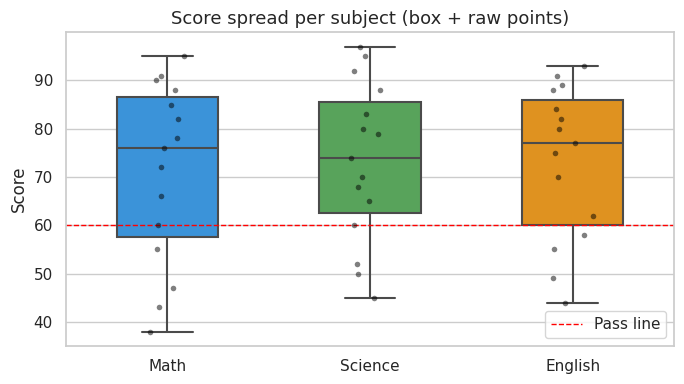

In [24]:
# Melt three score columns into a long-format DataFrame
df_long = df.melt(
    id_vars=['name', 'passed'],
    value_vars=['math_score', 'science_score', 'english_score'],
    var_name='subject', value_name='score'
)
df_long['subject'] = df_long['subject'].str.replace('_score', '').str.capitalize()

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=df_long, x='subject', y='score',
    hue='subject', palette=['#2196F3','#4CAF50','#FF9800'],
    width=0.5, linewidth=1.5, legend=False, ax=ax
)
sns.stripplot(
    data=df_long, x='subject', y='score',
    color='black', size=4, alpha=0.5, jitter=True, ax=ax
)

ax.axhline(60, color='red', linestyle='--', linewidth=1, label='Pass line')
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_title('Score spread per subject (box + raw points)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

### Chart 5 — KDE: attendance distribution by pass/fail

A KDE plot with `hue` shows whether passing and failing students have different attendance patterns — answering a real analytical question in two lines of code.

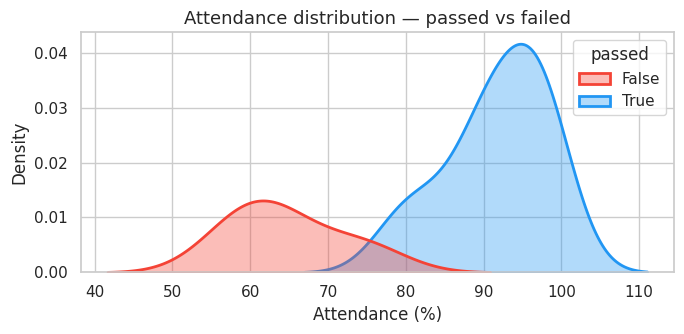

In [25]:
fig, ax = plt.subplots(figsize=(7, 3.5))

sns.kdeplot(
    data=df, x='attendance_pct',
    hue='passed',
    palette={True: '#2196F3', False: '#F44336'},
    fill=True, alpha=0.35, linewidth=2,
    ax=ax
)

ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Density')
ax.set_title('Attendance distribution — passed vs failed', fontsize=13)
plt.tight_layout()
plt.show()

### Chart 6 — Correlation heatmap

Which subjects move together? A heatmap of the correlation matrix answers that immediately. Values near +1 mean students who score high in one subject tend to score high in the other.

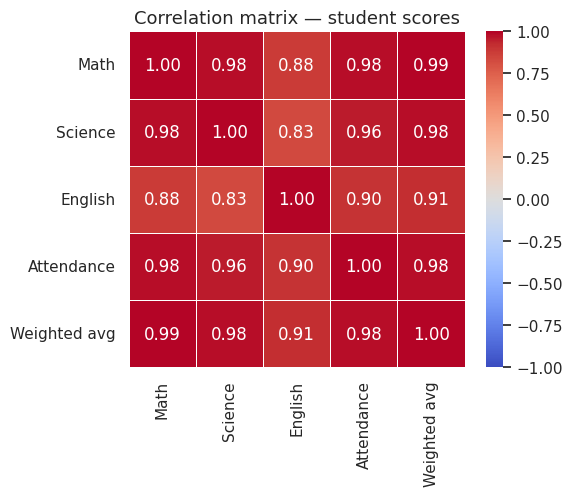

In [26]:
numeric_cols = ['math_score','science_score','english_score',
                'attendance_pct','weighted_avg']
corr = df[numeric_cols].corr()

# Rename for prettier axis labels
corr.index   = ['Math','Science','English','Attendance','Weighted avg']
corr.columns = ['Math','Science','English','Attendance','Weighted avg']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='coolwarm', vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation matrix — student scores', fontsize=13)
plt.tight_layout()
plt.show()

### Chart 7 — Full student performance dashboard

Combining everything into a single 2×3 figure. This is the pattern you'd use to build a one-page PDF summary for a teacher or manager — every panel tells one focused story, and `fig.suptitle` ties them together.

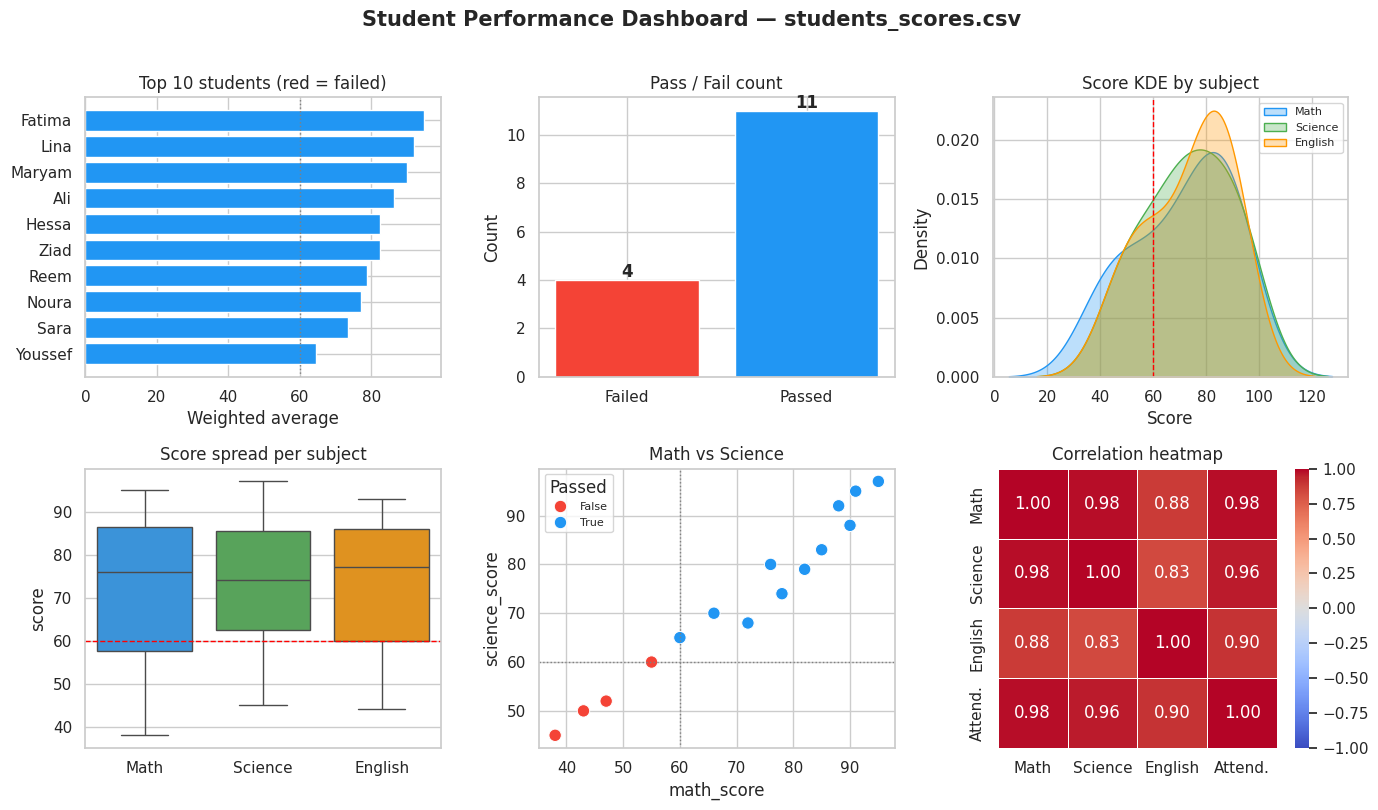

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# ── Panel 1: Top students ranked by weighted average ──────────────────
top = df.nlargest(10, 'weighted_avg')[['name','weighted_avg']].iloc[::-1]
colors = ['#F44336' if n in df[~df['passed']]['name'].values
          else '#2196F3' for n in top['name']]
axes[0,0].barh(top['name'].str.split().str[0], top['weighted_avg'], color=colors)
axes[0,0].axvline(60, color='grey', linestyle=':', linewidth=1)
axes[0,0].set_xlabel('Weighted average')
axes[0,0].set_title('Top 10 students (red = failed)')

# ── Panel 2: Pass/fail count ──────────────────────────────────────────
pass_counts = df['passed'].value_counts()
axes[0,1].bar(['Failed','Passed'],
              [pass_counts.get(False,0), pass_counts.get(True,0)],
              color=['#F44336','#2196F3'])
for rect in axes[0,1].patches:
    axes[0,1].text(rect.get_x()+rect.get_width()/2, rect.get_height()+0.1,
                   int(rect.get_height()), ha='center', fontweight='bold')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Pass / Fail count')

# ── Panel 3: Score distributions (hist + KDE) ────────────────────────
for col, color, label in zip(
    ['math_score','science_score','english_score'],
    ['#2196F3','#4CAF50','#FF9800'],
    ['Math','Science','English']):
    sns.kdeplot(df[col], ax=axes[0,2], color=color, fill=True, alpha=0.3, label=label)
axes[0,2].axvline(60, color='red', linestyle='--', linewidth=1)
axes[0,2].set_xlabel('Score'); axes[0,2].set_title('Score KDE by subject')
axes[0,2].legend(fontsize=8)

# ── Panel 4: Box plot per subject ─────────────────────────────────────
sns.boxplot(data=df_long, x='subject', y='score',
            hue='subject', palette=['#2196F3','#4CAF50','#FF9800'],
            legend=False, ax=axes[1,0])
axes[1,0].axhline(60, color='red', linestyle='--', linewidth=1)
axes[1,0].set_xlabel(''); axes[1,0].set_title('Score spread per subject')

# ── Panel 5: Math vs Science scatter ──────────────────────────────────
sns.scatterplot(data=df, x='math_score', y='science_score', hue='passed',
                palette={True:'#2196F3', False:'#F44336'},
                s=80, ax=axes[1,1])
axes[1,1].axvline(60, color='grey', linestyle=':', linewidth=1)
axes[1,1].axhline(60, color='grey', linestyle=':', linewidth=1)
axes[1,1].set_title('Math vs Science')
axes[1,1].legend(title='Passed', fontsize=8)

# ── Panel 6: Correlation heatmap ──────────────────────────────────────
corr2 = df[['math_score','science_score','english_score','attendance_pct']].corr()
corr2.index = corr2.columns = ['Math','Science','English','Attend.']
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.4, ax=axes[1,2])
axes[1,2].set_title('Correlation heatmap')

fig.suptitle('Student Performance Dashboard — students_scores.csv',
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()

> **Key takeaways — visualising CSV data**
>
> | Step | Code |
> |---|---|
> | Load & enrich | `df = pd.read_csv(...)` then `.assign()` for derived columns |
> | Bar chart | `ax.barh(labels, values)` + `ax.text(...)` to annotate |
> | Overlapping histograms | loop over columns → `sns.histplot(..., alpha=0.45)` |
> | Scatter with labels | `sns.scatterplot(hue=...)` + `ax.annotate` per row |
> | Box + raw points | `sns.boxplot` then `sns.stripplot` on the same `ax` |
> | Wide → long | `df.melt(value_vars=[...], var_name=..., value_name=...)` |
> | KDE by group | `sns.kdeplot(hue='passed', fill=True)` |
> | Correlation matrix | `df[cols].corr()` → `sns.heatmap(annot=True)` |
> | Dashboard | `plt.subplots(2, 3)` + one plot per `axes[r, c]` |
>
> The `df_long` long-format DataFrame created in Chart 4 is reused in the dashboard. > Preparing data in long format once and reusing it across plots is a clean habit.

---

## Worked Examples

### Example 1 — A 4-panel sales dashboard

A complete dashboard from one DataFrame: KPI history, breakdown by product, distribution of order sizes, and correlation between metrics.

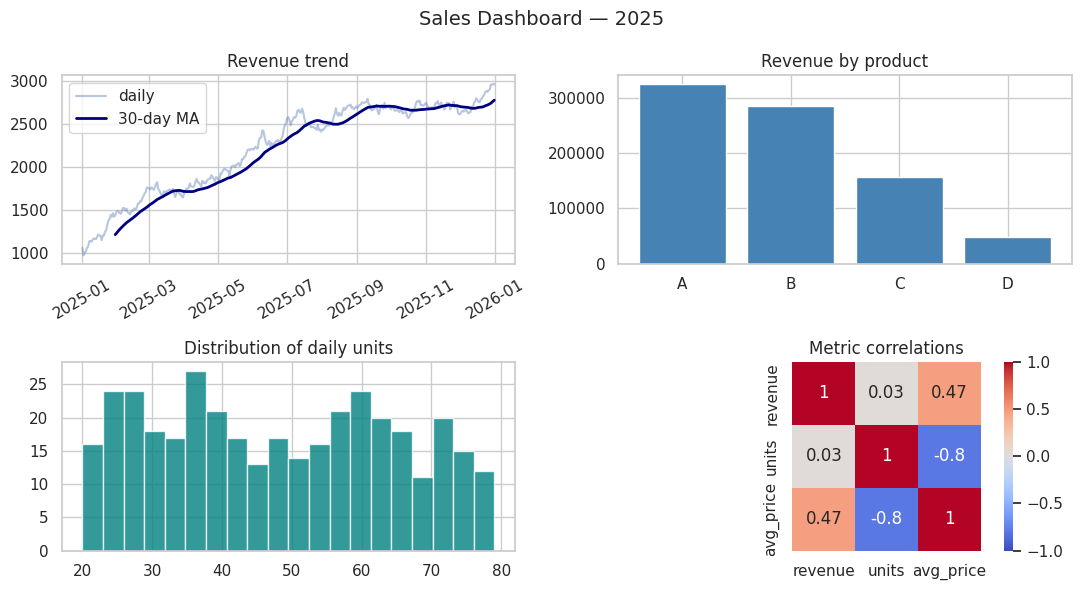

In [28]:
rng = np.random.default_rng(13)
n = 365

# -- Synthesize daily sales data -----------------------------------------------
dates = pd.date_range('2025-01-01', periods=n, freq='D')
sales = pd.DataFrame({
    'date':    dates,
    'revenue': 1000 + np.cumsum(rng.normal(5, 30, n)),
    'units':   rng.integers(20, 80, n),
    'product': rng.choice(['A', 'B', 'C', 'D'], n, p=[0.4, 0.3, 0.2, 0.1]),
})
sales['avg_price'] = sales['revenue'] / sales['units']

# -- Build the dashboard -------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

# Top-left: revenue trend with rolling mean
axes[0, 0].plot(sales['date'], sales['revenue'], alpha=0.4, label='daily')
axes[0, 0].plot(sales['date'],
                sales['revenue'].rolling(30).mean(),
                color='navy', linewidth=2, label='30-day MA')
axes[0, 0].set_title('Revenue trend'); axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=30)

# Top-right: revenue by product
prod = sales.groupby('product')['revenue'].sum().sort_values(ascending=False)
axes[0, 1].bar(prod.index, prod.values, color='steelblue')
axes[0, 1].set_title('Revenue by product')

# Bottom-left: units distribution
axes[1, 0].hist(sales['units'], bins=20, color='teal', alpha=0.8)
axes[1, 0].set_title('Distribution of daily units')

# Bottom-right: correlation heatmap
corr = sales.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',
            vmin=-1, vmax=1, square=True, ax=axes[1, 1])
axes[1, 1].set_title('Metric correlations')

fig.suptitle('Sales Dashboard — 2025', fontsize=14)
fig.tight_layout()
plt.show()

### Example 2 — Annotated time series

A line chart with a rolling mean overlay and labeled events.

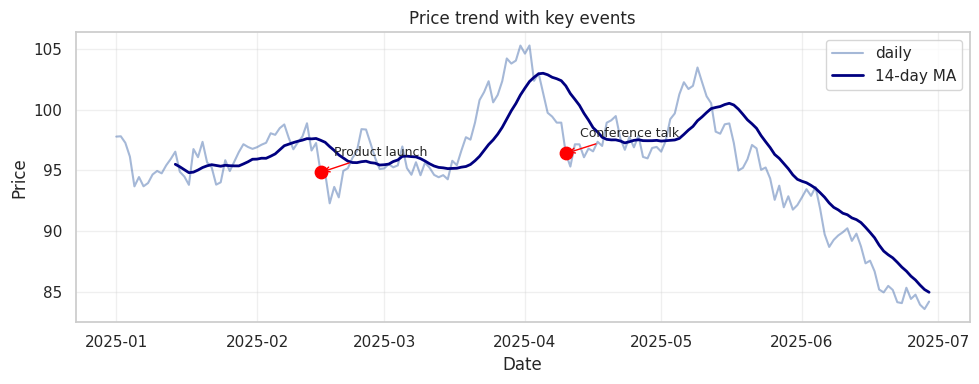

In [29]:
rng = np.random.default_rng(2025)
dates = pd.date_range('2025-01-01', periods=180, freq='D')
price = 100 + np.cumsum(rng.normal(0, 1.0, 180))
ts = pd.DataFrame({'date': dates, 'price': price})

# -- Plot ----------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ts['date'], ts['price'], alpha=0.5, label='daily')
ax.plot(ts['date'], ts['price'].rolling(14).mean(),
        color='navy', linewidth=2, label='14-day MA')

# -- Annotate two events -------------------------------------------------------
events = {'2025-02-15': 'Product launch',
          '2025-04-10': 'Conference talk'}
for date_str, label in events.items():
    d = pd.Timestamp(date_str)
    p = ts.loc[ts['date'] == d, 'price'].iloc[0]
    ax.scatter([d], [p], s=80, color='red', zorder=5)
    ax.annotate(label, xy=(d, p), xytext=(10, 12), textcoords='offset points',
                fontsize=9, arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title('Price trend with key events')
ax.set_xlabel('Date'); ax.set_ylabel('Price')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Example 3 — Distribution comparison across groups

Compare the distribution of a metric across categories using both a violin plot and a strip plot, on the same Axes.

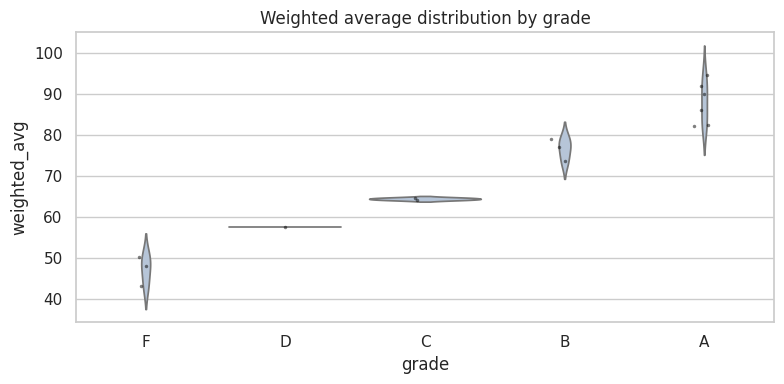

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))

# Violin shows the density; stripplot overlays the raw points
sns.violinplot(data=df, x='grade', y='weighted_avg', inner=None,
               color='lightsteelblue', ax=ax)
sns.stripplot(data=df, x='grade', y='weighted_avg',
              size=2.5, color='black', alpha=0.5, ax=ax)

ax.set_title('Weighted average distribution by grade')
plt.tight_layout(); plt.show()

### Example 4 — Two-way pivot heatmap

Mean score for every (`dept`, `gender`) combination, shown as a heatmap.

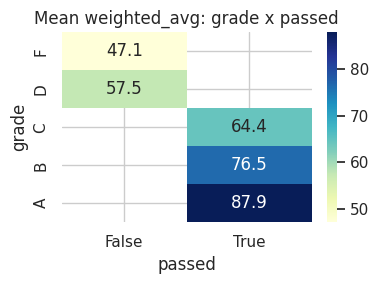

In [31]:
pivot = df.pivot_table(values='weighted_avg', index='grade', columns='passed', aggfunc='mean', observed=False)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax)
ax.set_title('Mean weighted_avg: grade x passed')
plt.tight_layout(); plt.show()

## Summary

| Concept | Key Point |
|---|---|
| **Matplotlib Architecture** | Figure (canvas), Axes (plot area), Artist (elements) |
| **Pyplot vs. OO Style** | Pyplot for quick plots, OO for complex/customized plots |
| **Basic Charts** | Line, scatter, bar, histogram, pie for different data types |
| **Customization** | Control colors, styles, legends, titles, labels, grids |
| **Subplots** | Arrange multiple plots in a single figure |
| **Saving Figures** | `savefig` with `dpi` and `bbox_inches` for quality output |
| **Seaborn** | High-level API for statistical plotting, native DataFrame support |
| **Distribution Plots** | `histplot`, `kdeplot`, `ecdfplot` to show data spread |
| **Categorical Plots** | `boxplot`, `violinplot`, `barplot`, `countplot` for category comparison |
| **Relational Plots** | `scatterplot` with `hue`, `size`, `style` for multi-dimensional data |
| **Heatmaps** | `sns.heatmap` for correlation matrices and other grid data |
| **Pair Plots** | `sns.pairplot` to visualize relationships between all numeric pairs |

### Contributed by: Abdulhadi Zubailah